# ANALISI SU DATAFRAME A LIVELLO COMUNALE CON DF AGGREGATO DAL 2001 AL 2024

L'analisi temporale ha evidenziato un trend decrescente degli incidenti nel periodo 2001-2024. Tuttavia, questa analisi non considera le differenze strutturali tra i comuni. Per questo motivo, nel notebook successivo viene effettuata un'analisi a livello comunale, aggregando gli incidenti sull'intero periodo (2001-2024) e studiando come caratteristiche demografiche e territoriali influenzino l'incidentalità.

# LIBRERIE

In [112]:
import pandas as pd
import os
import FUNCTIONS as fn

#grafici
import seaborn as sns
import matplotlib 
import matplotlib.pyplot as plt

# ANALISI ESPLORATIVA INTRO 

Carico i tre df, quello totale, quello solo degli incidenti, quello dei feriti e quello dei morti. Tutti questi presentano registrazioni dall' anno 2001 al 2024

In [113]:
os.getcwd()

'c:\\Users\\eliav\\Desktop\\Road_accidents_analysis\\Notebooks'

In [114]:
os.listdir()

['00_FIXED_fetching.ipynb',
 '01_FIXED_cleanind_overview.ipynb',
 '02a.EDA_&_Temporal_analysis.ipynb',
 '02b_EDA_Municipality_analysis_aggregate_01_24.ipynb',
 '03b_Test.ipynb',
 'FUNCTIONS.py',
 '__pycache__']

In [115]:
os.listdir("../Data/Df_clean")

['df_accidents_municipality_aggregate_years.csv',
 'df_feriti_from_01_to_24.csv',
 'df_final_from_01_to_24_clean.csv',
 'df_incidenti_from_01_to_24.csv',
 'df_morti_from_01_to_24.csv']

In [116]:
df_total= pd.read_csv ("../Data/Df_clean/df_final_from_01_to_24_clean.csv")
df_total

,ID_COMUNE,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,ID_REGIONE,ID_PROVINCIA,COMUNE,CAPOLUOGO PROVINCIA,CAPOLUOGO REGIONE,SUPERFICIE (KMQ),RESIDENTI,REGIONE
0,1001,morti_e_feriti,feriti,2001,10,1,1,Agliè,0,0,13.1462,2557,Piemonte
1,1001,morti_e_feriti,feriti,2002,10,1,1,Agliè,0,0,13.1462,2538,Piemonte
2,1001,morti_e_feriti,feriti,2003,7,1,1,Agliè,0,0,13.1462,2588,Piemonte
3,1001,morti_e_feriti,feriti,2004,13,1,1,Agliè,0,0,13.1462,2679,Piemonte
4,1001,morti_e_feriti,feriti,2005,2,1,1,Agliè,0,0,13.1462,2674,Piemonte
...,...,...,...,...,...,...,...,...,...,...,...,...,...
572695,111107,incidenti_stradali,incidenti,2020,2,20,111,Villaspeciosa,0,0,27.1937,2549,Sardegna
572696,111107,incidenti_stradali,incidenti,2021,5,20,111,Villaspeciosa,0,0,27.1943,2536,Sardegna
572697,111107,incidenti_stradali,incidenti,2022,1,20,111,Villaspeciosa,0,0,27.1943,2575,Sardegna
572698,111107,incidenti_stradali,incidenti,2023,4,20,111,Villaspeciosa,0,0,27.1943,2616,Sardegna


In [117]:
df_accidents= pd.read_csv ("../Data/Df_clean/df_incidenti_from_01_to_24.csv")
df_accidents

,ID_COMUNE,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,ID_REGIONE,ID_PROVINCIA,COMUNE,CAPOLUOGO PROVINCIA,CAPOLUOGO REGIONE,SUPERFICIE (KMQ),RESIDENTI,REGIONE
0,1001,incidenti_stradali,incidenti,2001,5,1,1,Agliè,0,0,13.1462,2557,Piemonte
1,1001,incidenti_stradali,incidenti,2002,5,1,1,Agliè,0,0,13.1462,2538,Piemonte
2,1001,incidenti_stradali,incidenti,2003,4,1,1,Agliè,0,0,13.1462,2588,Piemonte
3,1001,incidenti_stradali,incidenti,2004,9,1,1,Agliè,0,0,13.1462,2679,Piemonte
4,1001,incidenti_stradali,incidenti,2005,2,1,1,Agliè,0,0,13.1462,2674,Piemonte
...,...,...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,incidenti_stradali,incidenti,2020,2,20,111,Villaspeciosa,0,0,27.1937,2549,Sardegna
190896,111107,incidenti_stradali,incidenti,2021,5,20,111,Villaspeciosa,0,0,27.1943,2536,Sardegna
190897,111107,incidenti_stradali,incidenti,2022,1,20,111,Villaspeciosa,0,0,27.1943,2575,Sardegna
190898,111107,incidenti_stradali,incidenti,2023,4,20,111,Villaspeciosa,0,0,27.1943,2616,Sardegna


In [118]:
df_wounded= pd.read_csv ("../Data/Df_clean/df_feriti_from_01_to_24.csv")
df_wounded

,ID_COMUNE,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,ID_REGIONE,ID_PROVINCIA,COMUNE,CAPOLUOGO PROVINCIA,CAPOLUOGO REGIONE,SUPERFICIE (KMQ),RESIDENTI,REGIONE
0,1001,morti_e_feriti,feriti,2001,10,1,1,Agliè,0,0,13.1462,2557,Piemonte
1,1001,morti_e_feriti,feriti,2002,10,1,1,Agliè,0,0,13.1462,2538,Piemonte
2,1001,morti_e_feriti,feriti,2003,7,1,1,Agliè,0,0,13.1462,2588,Piemonte
3,1001,morti_e_feriti,feriti,2004,13,1,1,Agliè,0,0,13.1462,2679,Piemonte
4,1001,morti_e_feriti,feriti,2005,2,1,1,Agliè,0,0,13.1462,2674,Piemonte
...,...,...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,morti_e_feriti,feriti,2020,3,20,111,Villaspeciosa,0,0,27.1937,2549,Sardegna
190896,111107,morti_e_feriti,feriti,2021,7,20,111,Villaspeciosa,0,0,27.1943,2536,Sardegna
190897,111107,morti_e_feriti,feriti,2022,1,20,111,Villaspeciosa,0,0,27.1943,2575,Sardegna
190898,111107,morti_e_feriti,feriti,2023,5,20,111,Villaspeciosa,0,0,27.1943,2616,Sardegna


In [119]:
df_deaths= pd.read_csv ("../Data/Df_clean/df_morti_from_01_to_24.csv")
df_deaths

,ID_COMUNE,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,ID_REGIONE,ID_PROVINCIA,COMUNE,CAPOLUOGO PROVINCIA,CAPOLUOGO REGIONE,SUPERFICIE (KMQ),RESIDENTI,REGIONE
0,1001,morti_e_feriti,morti,2001,0,1,1,Agliè,0,0,13.1462,2557,Piemonte
1,1001,morti_e_feriti,morti,2002,0,1,1,Agliè,0,0,13.1462,2538,Piemonte
2,1001,morti_e_feriti,morti,2003,0,1,1,Agliè,0,0,13.1462,2588,Piemonte
3,1001,morti_e_feriti,morti,2004,0,1,1,Agliè,0,0,13.1462,2679,Piemonte
4,1001,morti_e_feriti,morti,2005,0,1,1,Agliè,0,0,13.1462,2674,Piemonte
...,...,...,...,...,...,...,...,...,...,...,...,...,...
190895,111107,morti_e_feriti,morti,2020,0,20,111,Villaspeciosa,0,0,27.1937,2549,Sardegna
190896,111107,morti_e_feriti,morti,2021,0,20,111,Villaspeciosa,0,0,27.1943,2536,Sardegna
190897,111107,morti_e_feriti,morti,2022,0,20,111,Villaspeciosa,0,0,27.1943,2575,Sardegna
190898,111107,morti_e_feriti,morti,2023,0,20,111,Villaspeciosa,0,0,27.1943,2616,Sardegna


# EDA

## RAGGRUPPO INCIDENTI/FERITI/MORTI PER COMUNE aggregando gli anni dal 01 al 24 e creazioni colonne con numero di osservazioni medie per anno, densità della superficie media, densità delle osservazioni media e incidenti pro capite medi (feature engineering)

In [120]:
df_accidents_municipality = fn.create_municipality_dataset(df_accidents,value_name="INCIDENTI")

In [121]:
df_wounded_municipality = fn.create_municipality_dataset(df_wounded,value_name="FERITI")

In [122]:
df_deaths_municipality = fn.create_municipality_dataset(df_deaths,value_name="MORTI")

AGGIUNTA COLONNE CLASSIFICAZIONE IN BASE A CLASSE DEMOGRAFICA E DI SUPERFICIE (al df_accidents_municipality)

Creo le colonne per la classificazione dei comuni in base alla superficie e alla demografia secondo la classificazione ufficiale:

-Classificazione Comuni per superficie -> https://www.istat.it/it/files/2015/04/Superfici-delle-unit%C3%A0-amministrative-Testo-integrale.pdf

-Classificazione comuni per classe demografica (da comprimere) ->https://finanzalocale.interno.gov.it/docum/studi/varie/200707varclass.html#due

In [123]:
#ANDANDO AD ANALIZZARE I COMUNI, VOGLIO CAPIRE ANCHE QUALI SIANO LE DIFFERENZE
# TRA CLASSI DEMOGRAFICHE E QUELLE DI SUPERFICIE, DUNQUE LI CLASSIFICO IN COLONNE
df_accidents_municipality["CLASSE_DEMOGRAFICA"] = ""

for i in df_accidents_municipality.index:

    residenti = df_accidents_municipality.loc[i, "RESIDENTI"]

    if residenti < 1000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Molto piccolo"
    elif residenti < 5000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Piccolo"
    elif residenti < 20000:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Medio"

    else:
        df_accidents_municipality.loc[i, "CLASSE_DEMOGRAFICA"] = "Grande"


df_accidents_municipality["CLASSE_SUPERFICIE"] = ""

for i in df_accidents_municipality.index:

    superficie = df_accidents_municipality.loc[i, "SUPERFICIE (KMQ)"]

    if superficie < 10:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Molto piccolo"
    elif superficie < 50:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Piccolo"
    elif superficie < 100:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Medio"
    elif superficie < 250:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Grande"

    else:
        df_accidents_municipality.loc[i, "CLASSE_SUPERFICIE"] = "Molto grande"

In [124]:
print(df_accidents_municipality["CLASSE_DEMOGRAFICA"].value_counts())
print("-"*50)
print(df_accidents_municipality["CLASSE_SUPERFICIE"].value_counts())
print("-"*50)
#Totale dei miei comuni
tot_df = len(df_accidents_municipality)
print("Totale dei comuni registrati: ",tot_df)

CLASSE_DEMOGRAFICA
Piccolo          3977
Molto piccolo    2106
Medio            2000
Grande            531
Name: count, dtype: int64
--------------------------------------------------
CLASSE_SUPERFICIE
Piccolo          4950
Molto piccolo    1811
Medio            1187
Grande            591
Molto grande       75
Name: count, dtype: int64
--------------------------------------------------
Totale dei comuni registrati:  8614


In [125]:
#Creo le classi con i comuni per classe demografica con pochi residenti e con molti, dopodichè guardo quanto rappresentano ciascuna
#in % sul totale e farò lo stesso con i comuni per classe superficie, voglio vedere quanti sono e quanto pesino sul totale.
#Inoltre voglio osservare in % quanto pesa ogni variabile della classe sul totale dei record registrati nel df.
class_few_resident = df_accidents_municipality[df_accidents_municipality["CLASSE_DEMOGRAFICA"].isin(["Piccolo", "Molto piccolo"])]
class_many_resident = df_accidents_municipality[df_accidents_municipality["CLASSE_DEMOGRAFICA"].isin(["Medio", "Grande"])]
perc_few = len(class_few_resident) / tot_df * 100
perc_many = len(class_many_resident) / tot_df * 100


print ("="*40)
print ("IN BASE ALLA CLASSE DEMOGRAFICA")
print ("="*40)
print(f"Piccolo + Molto Piccolo: {len(class_few_resident)} comuni ({perc_few:.2f}%)")
print(f"Medio + Grande: {len(class_many_resident)} comuni ({perc_many:.2f}%)")
print ("."*40)
fn.check_class_municipal(df_accidents_municipality,"CLASSE_DEMOGRAFICA","Grande")
fn.check_class_municipal(df_accidents_municipality,"CLASSE_DEMOGRAFICA","Medio")
fn.check_class_municipal(df_accidents_municipality,"CLASSE_DEMOGRAFICA","Piccolo")
fn.check_class_municipal(df_accidents_municipality,"CLASSE_DEMOGRAFICA","Molto piccolo")


IN BASE ALLA CLASSE DEMOGRAFICA
Piccolo + Molto Piccolo: 6083 comuni (70.62%)
Medio + Grande: 2531 comuni (29.38%)
........................................
Comuni 'Grande': 531 (6.16%)
Comuni 'Medio': 2000 (23.22%)
Comuni 'Piccolo': 3977 (46.17%)
Comuni 'Molto piccolo': 2106 (24.45%)


La distribuzione dei comuni in base alla classe demografica propende verso i comuni piccoli e molto piccoli, nella cella successiva osserverò se accadrà la stessa cosa con la classe di superficie.

In [126]:
class_few_sup = df_accidents_municipality[df_accidents_municipality["CLASSE_SUPERFICIE"].isin(["Piccolo", "Molto piccolo"])]
class_many_sup = df_accidents_municipality[df_accidents_municipality["CLASSE_SUPERFICIE"].isin(["Medio", "Grande", "Molto grande"])]
perc_few = len(class_few_sup) / tot_df * 100
perc_many = len(class_many_sup) / tot_df * 100

print ("="*40)
print ("IN BASE ALLA CLASSE DI SUPERFICIE")
print ("="*40)
print(f"Piccolo + Molto Piccolo: {len(class_few_sup)} comuni ({perc_few:.2f}%)")
print(f"Medio + Grande+ Molto grande: {len(class_many_sup)} comuni ({perc_many:.2f}%)")
print ("."*40)
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Molto grande")
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Grande")
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Medio")
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Piccolo")
fn.check_class_municipal (df_accidents_municipality,"CLASSE_SUPERFICIE","Molto piccolo")


IN BASE ALLA CLASSE DI SUPERFICIE
Piccolo + Molto Piccolo: 6761 comuni (78.49%)
Medio + Grande+ Molto grande: 1853 comuni (21.51%)
........................................
Comuni 'Molto grande': 75 (0.87%)
Comuni 'Grande': 591 (6.86%)
Comuni 'Medio': 1187 (13.78%)
Comuni 'Piccolo': 4950 (57.46%)
Comuni 'Molto piccolo': 1811 (21.02%)


La distribuzione viene confermata anche per la classe di superficie, in cui la maggioranza dei comuni si trova nelle classi "Piccolo" e "Molto piccolo"

## DATA OVERVIEW e CLEANING CHECK

Prima di iniziare con l' analisi esplorativa ricontrollo la pulizia dei dati del mio df

In [127]:
df_accidents_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_COMUNE                         8614 non-null   int64  
 1   COMUNE                            8614 non-null   str    
 2   INCIDENTI_TOTALI                  8614 non-null   int64  
 3   RESIDENTI                         8614 non-null   float64
 4   SUPERFICIE (KMQ)                  8614 non-null   float64
 5   ID_REGIONE                        8614 non-null   int64  
 6   REGIONE                           8614 non-null   str    
 7   INCIDENTI_MEDI_ANNUI              8614 non-null   float64
 8   DENSITA_POPOLAZIONE               8614 non-null   float64
 9   DENSITA_INCIDENTI_MEDIA           8614 non-null   float64
 10  INCIDENTI_PRO_CAPITE(1000)_MEDIA  8614 non-null   float64
 11  CLASSE_DEMOGRAFICA                8614 non-null   str    
 12  CLASSE_SUPERFICIE

In [128]:
df_wounded_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_COMUNE                      8614 non-null   int64  
 1   COMUNE                         8614 non-null   str    
 2   FERITI_TOTALI                  8614 non-null   int64  
 3   RESIDENTI                      8614 non-null   float64
 4   SUPERFICIE (KMQ)               8614 non-null   float64
 5   ID_REGIONE                     8614 non-null   int64  
 6   REGIONE                        8614 non-null   str    
 7   FERITI_MEDI_ANNUI              8614 non-null   float64
 8   DENSITA_POPOLAZIONE            8614 non-null   float64
 9   DENSITA_FERITI_MEDIA           8614 non-null   float64
 10  FERITI_PRO_CAPITE(1000)_MEDIA  8614 non-null   float64
dtypes: float64(6), int64(3), str(2)
memory usage: 740.4 KB


In [129]:
df_deaths_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_COMUNE                     8614 non-null   int64  
 1   COMUNE                        8614 non-null   str    
 2   MORTI_TOTALI                  8614 non-null   int64  
 3   RESIDENTI                     8614 non-null   float64
 4   SUPERFICIE (KMQ)              8614 non-null   float64
 5   ID_REGIONE                    8614 non-null   int64  
 6   REGIONE                       8614 non-null   str    
 7   MORTI_MEDI_ANNUI              8614 non-null   float64
 8   DENSITA_POPOLAZIONE           8614 non-null   float64
 9   DENSITA_MORTI_MEDIA           8614 non-null   float64
 10  MORTI_PRO_CAPITE(1000)_MEDIA  8614 non-null   float64
dtypes: float64(6), int64(3), str(2)
memory usage: 740.4 KB


In [130]:
def change_type_col_Int64 (df, col):
    df[col] = (df[col].astype("int64"))

In [131]:
change_type_col_Int64(df_accidents_municipality,"ID_REGIONE")
change_type_col_Int64(df_wounded_municipality,"ID_REGIONE")
change_type_col_Int64(df_deaths_municipality,"ID_REGIONE")

In [132]:
fn.check_df (df_accidents_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_COMUNE                         8614 non-null   int64  
 1   COMUNE                            8614 non-null   str    
 2   INCIDENTI_TOTALI                  8614 non-null   int64  
 3   RESIDENTI                         8614 non-null   float64
 4   SUPERFICIE (KMQ)                  8614 non-null   float64
 5   ID_REGIONE                        8614 non-null   int64  
 6   REGIONE                           8614 non-null   str    
 7   INCIDENTI_MEDI_ANNUI              8614 non-null   float64
 8   DENSITA_POPOLAZIONE               8614 non-null   float64
 9   DENSITA_INCIDENTI_MEDIA           8614 non-null   float64
 10  INCIDENTI_PRO_CAPITE(1000)_MEDIA  8614 non-null   float64
 11  CLASSE_DEMOGRAFICA                8614 non-null   str    
 12  CLASSE_SUPERFICIE

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
0,1001,Agliè,95,2630.541667,13.146217,1,Piemonte,3.958333,200.098761,0.301101,1.504760,Piccolo,Piccolo
1,1002,Airasca,262,3699.041667,15.739300,1,Piemonte,10.916667,235.019452,0.693593,2.951215,Piccolo,Piccolo
2,1003,Ala di Stura,6,463.875000,46.331517,1,Piemonte,0.250000,10.012083,0.005396,0.538938,Molto piccolo,Piccolo
3,1004,Albiano d'Ivrea,107,1696.000000,11.732788,1,Piemonte,4.458333,144.552179,0.379989,2.628734,Piccolo,Piccolo
4,1005,Alice Superiore,21,687.222222,7.379600,1,Piemonte,0.875000,93.124590,0.118570,1.273242,Molto piccolo,Molto piccolo


In [133]:
fn.check_df (df_wounded_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_COMUNE                      8614 non-null   int64  
 1   COMUNE                         8614 non-null   str    
 2   FERITI_TOTALI                  8614 non-null   int64  
 3   RESIDENTI                      8614 non-null   float64
 4   SUPERFICIE (KMQ)               8614 non-null   float64
 5   ID_REGIONE                     8614 non-null   int64  
 6   REGIONE                        8614 non-null   str    
 7   FERITI_MEDI_ANNUI              8614 non-null   float64
 8   DENSITA_POPOLAZIONE            8614 non-null   float64
 9   DENSITA_FERITI_MEDIA           8614 non-null   float64
 10  FERITI_PRO_CAPITE(1000)_MEDIA  8614 non-null   float64
dtypes: float64(6), int64(3), str(2)
memory usage: 740.4 KB
None
----------------------------------------
Dati duplicati: 0


,ID_COMUNE,COMUNE,FERITI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,FERITI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_FERITI_MEDIA,FERITI_PRO_CAPITE(1000)_MEDIA
0,1001,Agliè,161,2630.541667,13.146217,1,Piemonte,6.708333,200.098761,0.510286,2.550172
1,1002,Airasca,427,3699.041667,15.739300,1,Piemonte,17.791667,235.019452,1.130398,4.809804
2,1003,Ala di Stura,10,463.875000,46.331517,1,Piemonte,0.416667,10.012083,0.008993,0.898230
3,1004,Albiano d'Ivrea,165,1696.000000,11.732788,1,Piemonte,6.875000,144.552179,0.585965,4.053656
4,1005,Alice Superiore,34,687.222222,7.379600,1,Piemonte,1.416667,93.124590,0.191971,2.061439


In [134]:
fn.check_df (df_deaths_municipality)

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID_COMUNE                     8614 non-null   int64  
 1   COMUNE                        8614 non-null   str    
 2   MORTI_TOTALI                  8614 non-null   int64  
 3   RESIDENTI                     8614 non-null   float64
 4   SUPERFICIE (KMQ)              8614 non-null   float64
 5   ID_REGIONE                    8614 non-null   int64  
 6   REGIONE                       8614 non-null   str    
 7   MORTI_MEDI_ANNUI              8614 non-null   float64
 8   DENSITA_POPOLAZIONE           8614 non-null   float64
 9   DENSITA_MORTI_MEDIA           8614 non-null   float64
 10  MORTI_PRO_CAPITE(1000)_MEDIA  8614 non-null   float64
dtypes: float64(6), int64(3), str(2)
memory usage: 740.4 KB
None
----------------------------------------
Dati duplicati: 0
-------------

,ID_COMUNE,COMUNE,MORTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,MORTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_MORTI_MEDIA,MORTI_PRO_CAPITE(1000)_MEDIA
0,1001,Agliè,1,2630.541667,13.146217,1,Piemonte,0.041667,200.098761,0.003169,0.015840
1,1002,Airasca,8,3699.041667,15.739300,1,Piemonte,0.333333,235.019452,0.021178,0.090113
2,1003,Ala di Stura,0,463.875000,46.331517,1,Piemonte,0.000000,10.012083,0.000000,0.000000
3,1004,Albiano d'Ivrea,10,1696.000000,11.732788,1,Piemonte,0.416667,144.552179,0.035513,0.245676
4,1005,Alice Superiore,5,687.222222,7.379600,1,Piemonte,0.208333,93.124590,0.028231,0.303153


# STATISTICA DESCRITTIVA

Voglio capire la distribuzione dei dati e vedere se ci sono punti di analisi interessanti

In [135]:
print("---- Incidenti ----")
display(df_accidents_municipality[["INCIDENTI_TOTALI","INCIDENTI_MEDI_ANNUI","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_INCIDENTI_MEDIA","INCIDENTI_PRO_CAPITE(1000)_MEDIA"]].describe())

print("---- Feriti ----")
display(df_wounded_municipality[["FERITI_TOTALI","FERITI_MEDI_ANNUI","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_FERITI_MEDIA","FERITI_PRO_CAPITE(1000)_MEDIA"]].describe())

print("---- Morti ----")
display(df_deaths_municipality[["MORTI_TOTALI","MORTI_MEDI_ANNUI","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_MORTI_MEDIA","MORTI_PRO_CAPITE(1000)_MEDIA"]].describe())

---- Incidenti ----


,INCIDENTI_TOTALI,INCIDENTI_MEDI_ANNUI,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA
count,8614.000000,8614.000000,8.614000e+03,8614.000000,8614.000000,8614.000000,8614.000000
mean,554.092640,23.087193,7.230314e+03,38.321339,294.240836,0.657839,1.832545
std,5734.537761,238.939073,3.950179e+04,50.713202,633.316850,1.828218,1.612039
min,0.000000,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,21.000000,0.875000,1.027006e+03,11.330942,44.207819,0.037220,0.724699
50%,78.000000,3.250000,2.418562e+03,22.349802,102.624523,0.146317,1.443655
75%,258.000000,10.750000,6.021292e+03,44.802008,264.942062,0.527222,2.474256
max,390605.000000,16275.208333,2.693100e+06,1287.499925,12215.874974,62.497866,23.194112


---- Feriti ----


,FERITI_TOTALI,FERITI_MEDI_ANNUI,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_FERITI_MEDIA,FERITI_PRO_CAPITE(1000)_MEDIA
count,8614.000000,8614.000000,8.614000e+03,8614.000000,8614.000000,8614.000000,8614.000000
mean,777.787671,32.407820,7.230314e+03,38.321339,294.240836,0.932124,2.727891
std,7507.108557,312.796190,3.950179e+04,50.713202,633.316850,2.452822,2.458929
min,0.000000,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,32.000000,1.333333,1.027006e+03,11.330942,44.207819,0.054994,1.062001
50%,118.000000,4.916667,2.418562e+03,22.349802,102.624523,0.220635,2.153912
75%,387.750000,16.156250,6.021292e+03,44.802008,264.942062,0.798943,3.673263
max,506345.000000,21097.708333,2.693100e+06,1287.499925,12215.874974,81.631438,37.230401


---- Morti ----


,MORTI_TOTALI,MORTI_MEDI_ANNUI,RESIDENTI,SUPERFICIE (KMQ),DENSITA_POPOLAZIONE,DENSITA_MORTI_MEDIA,MORTI_PRO_CAPITE(1000)_MEDIA
count,8614.000000,8614.000000,8.614000e+03,8614.000000,8614.000000,8614.000000,8614.000000
mean,11.819596,0.492483,7.230314e+03,38.321339,294.240836,0.016239,0.085181
std,58.211738,2.425489,3.950179e+04,50.713202,633.316850,0.025474,0.115768
min,0.000000,0.000000,3.586957e+01,0.120867,0.942396,0.000000,0.000000
25%,1.000000,0.041667,1.027006e+03,11.330942,44.207819,0.001579,0.023759
50%,4.000000,0.166667,2.418562e+03,22.349802,102.624523,0.007108,0.060810
75%,11.000000,0.458333,6.021292e+03,44.802008,264.942062,0.020592,0.109565
max,4350.000000,181.250000,2.693100e+06,1287.499925,12215.874974,0.329063,3.061768


# CLASSIFICHE

-COMUNE CON PIù INCIDENTI/ FERITI/ MORTI: Roma sia per incidenti che per morti e feriti

-REGIONE CON PIù INCIDENTI/ FERITI/ MORTI: Lombardia sia per incidenti che per morti e feriti

In [136]:
#COMUNE CON PIù INCIDENTI
#display(df_accidents_municipality.loc[df_accidents_municipality["INCIDENTI_TOTALI"].idxmax()]) # modo 1 -per trovare il valore più alto di incidenti
display(df_accidents_municipality.sort_values("INCIDENTI_TOTALI", ascending=False).head())
#COMUNE CON PIù FERITI
display(df_wounded_municipality.sort_values("FERITI_TOTALI", ascending=False).head()) # modo 2 -per trovare il valore più alto di feriti
#COMUNE CON PIù MORTI
display(df_deaths_municipality.sort_values("MORTI_TOTALI", ascending=False).head())

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5148,58091,Roma,390605,2.693100e+06,1287.499925,12,Lazio,16275.208333,2091.728018,12.640939,6.043300,Grande,Molto grande
1875,15146,Milano,272545,1.310566e+06,181.702871,3,Lombardia,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
1299,10025,Genova,102694,5.862910e+05,240.190217,7,Liguria,4278.916667,2440.944375,17.814700,7.298282,Grande,Grande
271,1272,Torino,87227,8.728376e+05,130.021463,1,Piemonte,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
4631,48017,Firenze,74537,3.646007e+05,102.315325,9,Toscana,3105.708333,3563.500466,30.354283,8.518108,Grande,Grande


,ID_COMUNE,COMUNE,FERITI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,FERITI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_FERITI_MEDIA,FERITI_PRO_CAPITE(1000)_MEDIA
5148,58091,Roma,506345,2.693100e+06,1287.499925,12,Lazio,21097.708333,2091.728018,16.386571,7.833987
1875,15146,Milano,355984,1.310566e+06,181.702871,3,Lombardia,14832.666667,7212.689425,81.631438,11.317753
271,1272,Torino,129752,8.728376e+05,130.021463,1,Piemonte,5406.333333,6713.027282,41.580315,6.193974
1299,10025,Genova,128139,5.862910e+05,240.190217,7,Liguria,5339.125000,2440.944375,22.228736,9.106613
4631,48017,Firenze,90339,3.646007e+05,102.315325,9,Toscana,3764.125000,3563.500466,36.789455,10.323965


,ID_COMUNE,COMUNE,MORTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,MORTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_MORTI_MEDIA,MORTI_PRO_CAPITE(1000)_MEDIA
5148,58091,Roma,4350,2.693100e+06,1287.499925,12,Lazio,181.250000,2091.728018,0.140777,0.067302
1875,15146,Milano,1435,1.310566e+06,181.702871,3,Lombardia,59.791667,7212.689425,0.329063,0.045623
271,1272,Torino,895,8.728376e+05,130.021463,1,Piemonte,37.291667,6713.027282,0.286812,0.042725
5533,63049,Napoli,881,9.588668e+05,118.998133,15,Campania,36.708333,8057.830529,0.308478,0.038283
7047,82053,Palermo,716,6.582088e+05,160.602017,19,Sicilia,29.833333,4098.384609,0.185759,0.045325


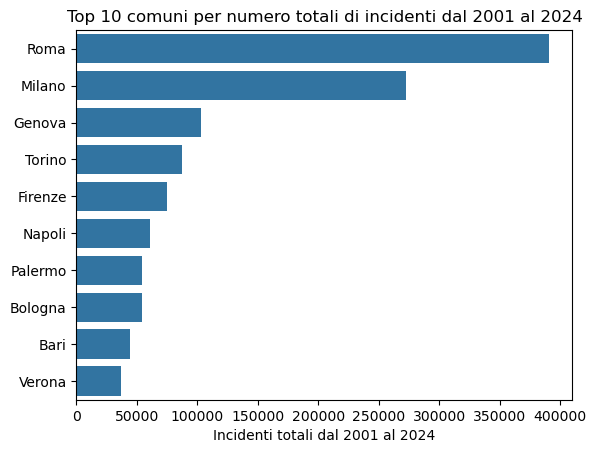

In [137]:
#BARPLOTS
top10 = (df_accidents_municipality.sort_values("INCIDENTI_TOTALI", ascending=False).head(10))

sns.barplot(data=top10,x="INCIDENTI_TOTALI",y="COMUNE")
plt.xlabel ("Incidenti totali dal 2001 al 2024")
plt.ylabel ("")
plt.title("Top 10 comuni per numero totali di incidenti dal 2001 al 2024")
plt.show()

In [138]:
display(df_accidents_municipality.groupby(["ID_REGIONE","REGIONE"], as_index=False)["INCIDENTI_TOTALI"].sum().sort_values("INCIDENTI_TOTALI", ascending=False).head()) #devo mettere as_index=false per far si che non esca una serie con indice l'id regionale
display(df_wounded_municipality.groupby(["ID_REGIONE","REGIONE"], as_index=False)["FERITI_TOTALI"].sum().sort_values("FERITI_TOTALI", ascending=False).head())
display(df_deaths_municipality.groupby(["ID_REGIONE","REGIONE"], as_index=False)["MORTI_TOTALI"].sum().sort_values("MORTI_TOTALI", ascending=False).head())


,ID_REGIONE,REGIONE,INCIDENTI_TOTALI
2,3,Lombardia,900236
11,12,Lazio,590275
7,8,Emilia-Romagna,477672
8,9,Toscana,424499
4,5,Veneto,373175


,ID_REGIONE,REGIONE,FERITI_TOTALI
2,3,Lombardia,1219236
11,12,Lazio,811262
7,8,Emilia-Romagna,649931
8,9,Toscana,559846
4,5,Veneto,513145


,ID_REGIONE,REGIONE,MORTI_TOTALI
2,3,Lombardia,14285
11,12,Lazio,10673
7,8,Emilia-Romagna,10587
4,5,Veneto,9836
0,1,Piemonte,7792


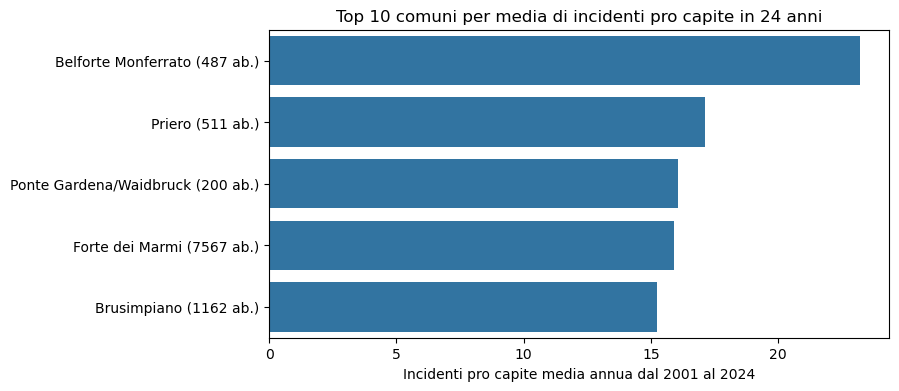

In [139]:
#BARPLOTS TOP 10 COMUNI INCIDENTI PRO CAPITE MEDI

top_pro_capite = (df_accidents_municipality.sort_values("INCIDENTI_PRO_CAPITE(1000)_MEDIA", ascending=False))
top_pro_capite["COMUNE"] = (top_pro_capite["COMUNE"] +" (" +
    top_pro_capite["RESIDENTI"].round().astype(int).astype(str) +
    " ab.)")

plt.figure(figsize=(8, 4))
sns.barplot(data=top_pro_capite.head(),x="INCIDENTI_PRO_CAPITE(1000)_MEDIA",y="COMUNE")
plt.xlabel ("Incidenti pro capite media annua dal 2001 al 2024")
plt.ylabel ("")
plt.title("Top 10 comuni per media di incidenti pro capite in 24 anni")
plt.show()

In [140]:
#voglio osservare le classi demografiche e di superficie di chi è in top incidenti pro capite--> sono principalmente molto piccoli, 1 piccolo e 1 medio (Forte Dei Marmi)
top_pro_capite

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
882,6014,Belforte Monferrato (487 ab.),271,486.833333,8.325800,1,Piemonte,11.291667,58.472859,1.356226,23.194112,Molto piccolo,Molto piccolo
670,4175,Priero (511 ab.),210,511.000000,19.976367,1,Piemonte,8.750000,25.580227,0.438018,17.123288,Molto piccolo,Piccolo
2868,21065,Ponte Gardena/Waidbruck (200 ab.),77,199.625000,2.317742,4,Trentino-Alto Adige,3.208333,86.129098,1.384250,16.071801,Molto piccolo,Molto piccolo
4568,46013,Forte dei Marmi (7567 ab.),2887,7567.291667,8.957700,9,Toscana,120.291667,844.780654,13.428856,15.896264,Medio,Molto piccolo
1398,12024,Brusimpiano (1162 ab.),425,1162.375000,5.905800,3,Lombardia,17.708333,196.819229,2.998465,15.234613,Piccolo,Molto piccolo
...,...,...,...,...,...,...,...,...,...,...,...,...,...
572,4077,Crissolo (174 ab.),0,174.434783,52.052900,1,Piemonte,0.000000,3.351106,0.000000,0.000000,Molto piccolo,Medio
6761,78126,San Pietro in Amantea (530 ab.),0,530.260870,9.844100,18,Calabria,0.000000,53.865856,0.000000,0.000000,Molto piccolo,Molto piccolo
6755,78120,San Lorenzo Bellizzi (713 ab.),0,713.043478,40.628243,18,Calabria,0.000000,17.550438,0.000000,0.000000,Molto piccolo,Piccolo
8530,111024,Genuri (311 ab.),0,310.714286,7.515243,20,Sardegna,0.000000,41.344544,0.000000,0.000000,Molto piccolo,Molto piccolo


# ANALISI UNIVARIATA (istogrammi, boxplot, barchart)

Da qui in poi farò l' analisi solamente sugli incidenti

Voglio osservare la distribuzione dei dati, essendo molto eterogenei utilizzerò una scala logaritmica però attenzione agli outlier, poichè le variabili vanno analizzate sui dati reali e non in scala

### Histograms & Boxplots 
Per vedere come sono distribuiti i dati

In [141]:
df_accidents_municipality.info()

<class 'pandas.DataFrame'>
RangeIndex: 8614 entries, 0 to 8613
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ID_COMUNE                         8614 non-null   int64  
 1   COMUNE                            8614 non-null   str    
 2   INCIDENTI_TOTALI                  8614 non-null   int64  
 3   RESIDENTI                         8614 non-null   float64
 4   SUPERFICIE (KMQ)                  8614 non-null   float64
 5   ID_REGIONE                        8614 non-null   int64  
 6   REGIONE                           8614 non-null   str    
 7   INCIDENTI_MEDI_ANNUI              8614 non-null   float64
 8   DENSITA_POPOLAZIONE               8614 non-null   float64
 9   DENSITA_INCIDENTI_MEDIA           8614 non-null   float64
 10  INCIDENTI_PRO_CAPITE(1000)_MEDIA  8614 non-null   float64
 11  CLASSE_DEMOGRAFICA                8614 non-null   str    
 12  CLASSE_SUPERFICIE

In [142]:
(df_accidents_municipality[["RESIDENTI","SUPERFICIE (KMQ)","INCIDENTI_MEDI_ANNUI", "DENSITA_INCIDENTI_MEDIA","INCIDENTI_PRO_CAPITE(1000)_MEDIA"]].describe()).round(2)

,RESIDENTI,SUPERFICIE (KMQ),INCIDENTI_MEDI_ANNUI,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA
count,8614.00,8614.00,8614.00,8614.00,8614.00
mean,7230.31,38.32,23.09,0.66,1.83
std,39501.79,50.71,238.94,1.83,1.61
min,35.87,0.12,0.00,0.00,0.00
25%,1027.01,11.33,0.88,0.04,0.72
50%,2418.56,22.35,3.25,0.15,1.44
75%,6021.29,44.80,10.75,0.53,2.47
max,2693099.67,1287.50,16275.21,62.50,23.19


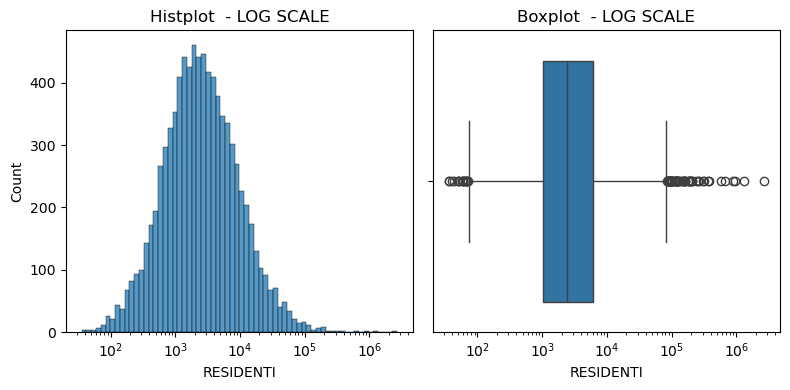

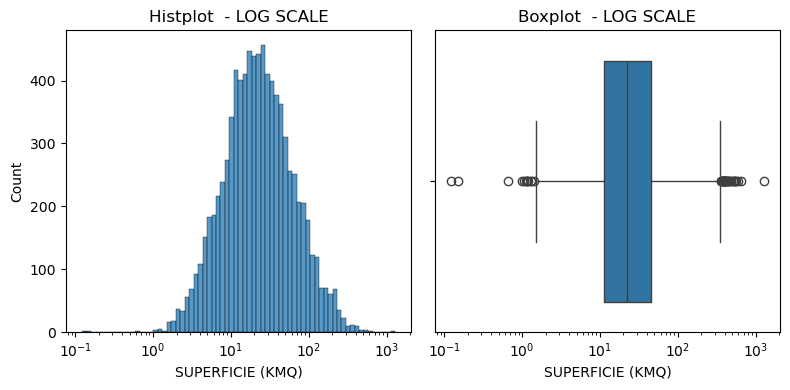

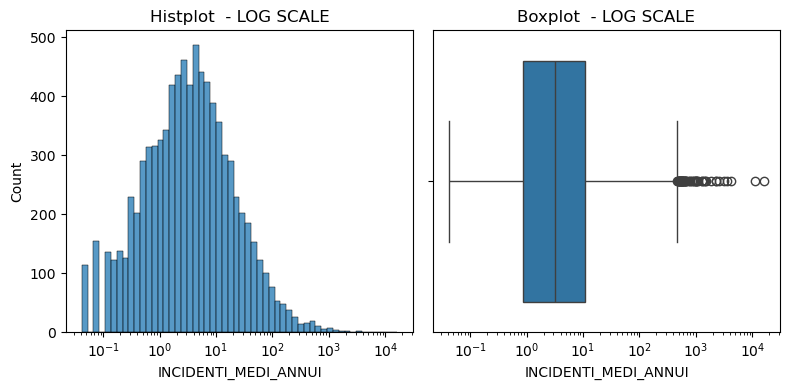

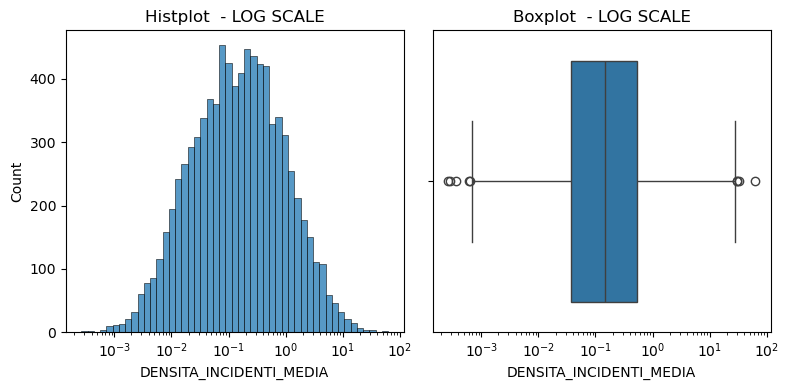

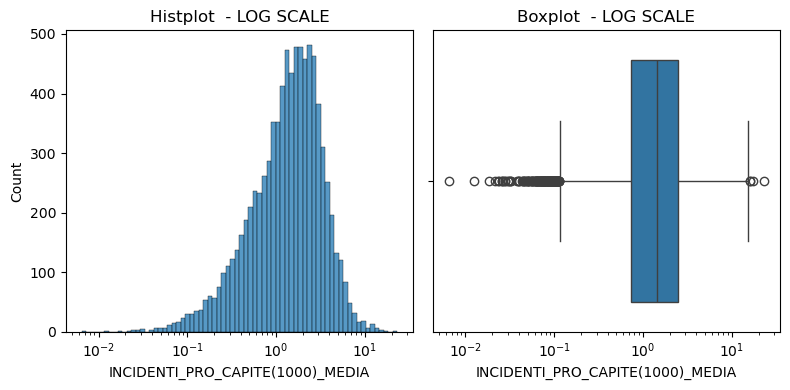

In [143]:
for col in ["RESIDENTI","SUPERFICIE (KMQ)","INCIDENTI_MEDI_ANNUI", "DENSITA_INCIDENTI_MEDIA","INCIDENTI_PRO_CAPITE(1000)_MEDIA"]:
    fn.plot_distr_logaritmic_scale(df_accidents_municipality, col)

Senza scala logaritmica noto che 

GRAFICI RESIDENTI: Distribuzione è asimmetrica a destra (right-skewed), vuol dire che ci sono tanti valori piccoli e pochi valori grandi o molto grandi, molti outlier oltre il Q3, comuni con molti residenti-->guardare outlier oltre Q3

GRAFICI SUPERFICIE: Distribuzione è asimmetrica a destra (right-skewed), vuol dire che ci sono tanti valori piccoli e pochi valori grandi o molto grandi, molti outlier oltre il Q3, comuni che ricoprono vasta area di superficie-->guardare outlier oltre Q3

GRAFICI INCIDENTI MEDI ANNUI-->dustribuzione asimmetrica a destra, ci sono pochi comuni con molti incidenti medi e sono outlier oltre il Q3--> osservare outlier oltr il Q3

GRAFICI DENSITA' INCIDENTI MEDIA-->dustribuzione asimmetrica a destra, ci sono pochi comuni che hanno molta densità di incidenti media e sono outlier oltre il Q3--> osservare outlier oltr il Q3

GRAFICI INCIDENTI PRO CAPITE MEDI-->dustribuzione asimmetrica a destra, ci sono pochi comuni con molti incidenti pro capite medi e sono outlier oltre il Q3--> osservare outlier oltr il Q3

Dall' analisi dei grafici ho notato che sostanzialmente la maggioranza dei valori delle variabili si aggira attorno ai valori piccoli


Asimmetria a destra: tanti valori piccoli e pochi valori molto grandi → è il caso tipico di popolazione, superficie e spesso anche degli incidenti.
Asimmetria a sinistra: tanti valori grandi e pochi molto piccoli.

- OBS_VALUE (Incidenti)

Si vede chiaramente che:

la distribuzione è fortemente asimmetrica a destra;
la maggior parte dei comuni registra poche decine o centinaia di incidenti;
pochi comuni raggiungono valori molto elevati.

Il boxplot conferma la presenza di numerosi outlier verso destra.


- DENSITA_INCIDENTI

L'istogramma sembra quasi una distribuzione normale se osservato sulla scala logaritmica. La trasformazione logaritmica ha reso la distribuzione molto più interpretabile.

Anche il boxplot è pulito.

- INCIDENTI_PRO_CAPITE

la distribuzione è ancora leggermente asimmetrica;
esistono outlier sia molto bassi sia molto alti.

Con la scala logaritmica riesci invece a vedere la forma della distribuzione.



Non ho cambiato i dati. Ho cambiato come li osservo.È la stessa differenza che c'è tra zoomare una foto e cambiare la foto.

# ANALISI BIVARIATA (Scatterplot...)

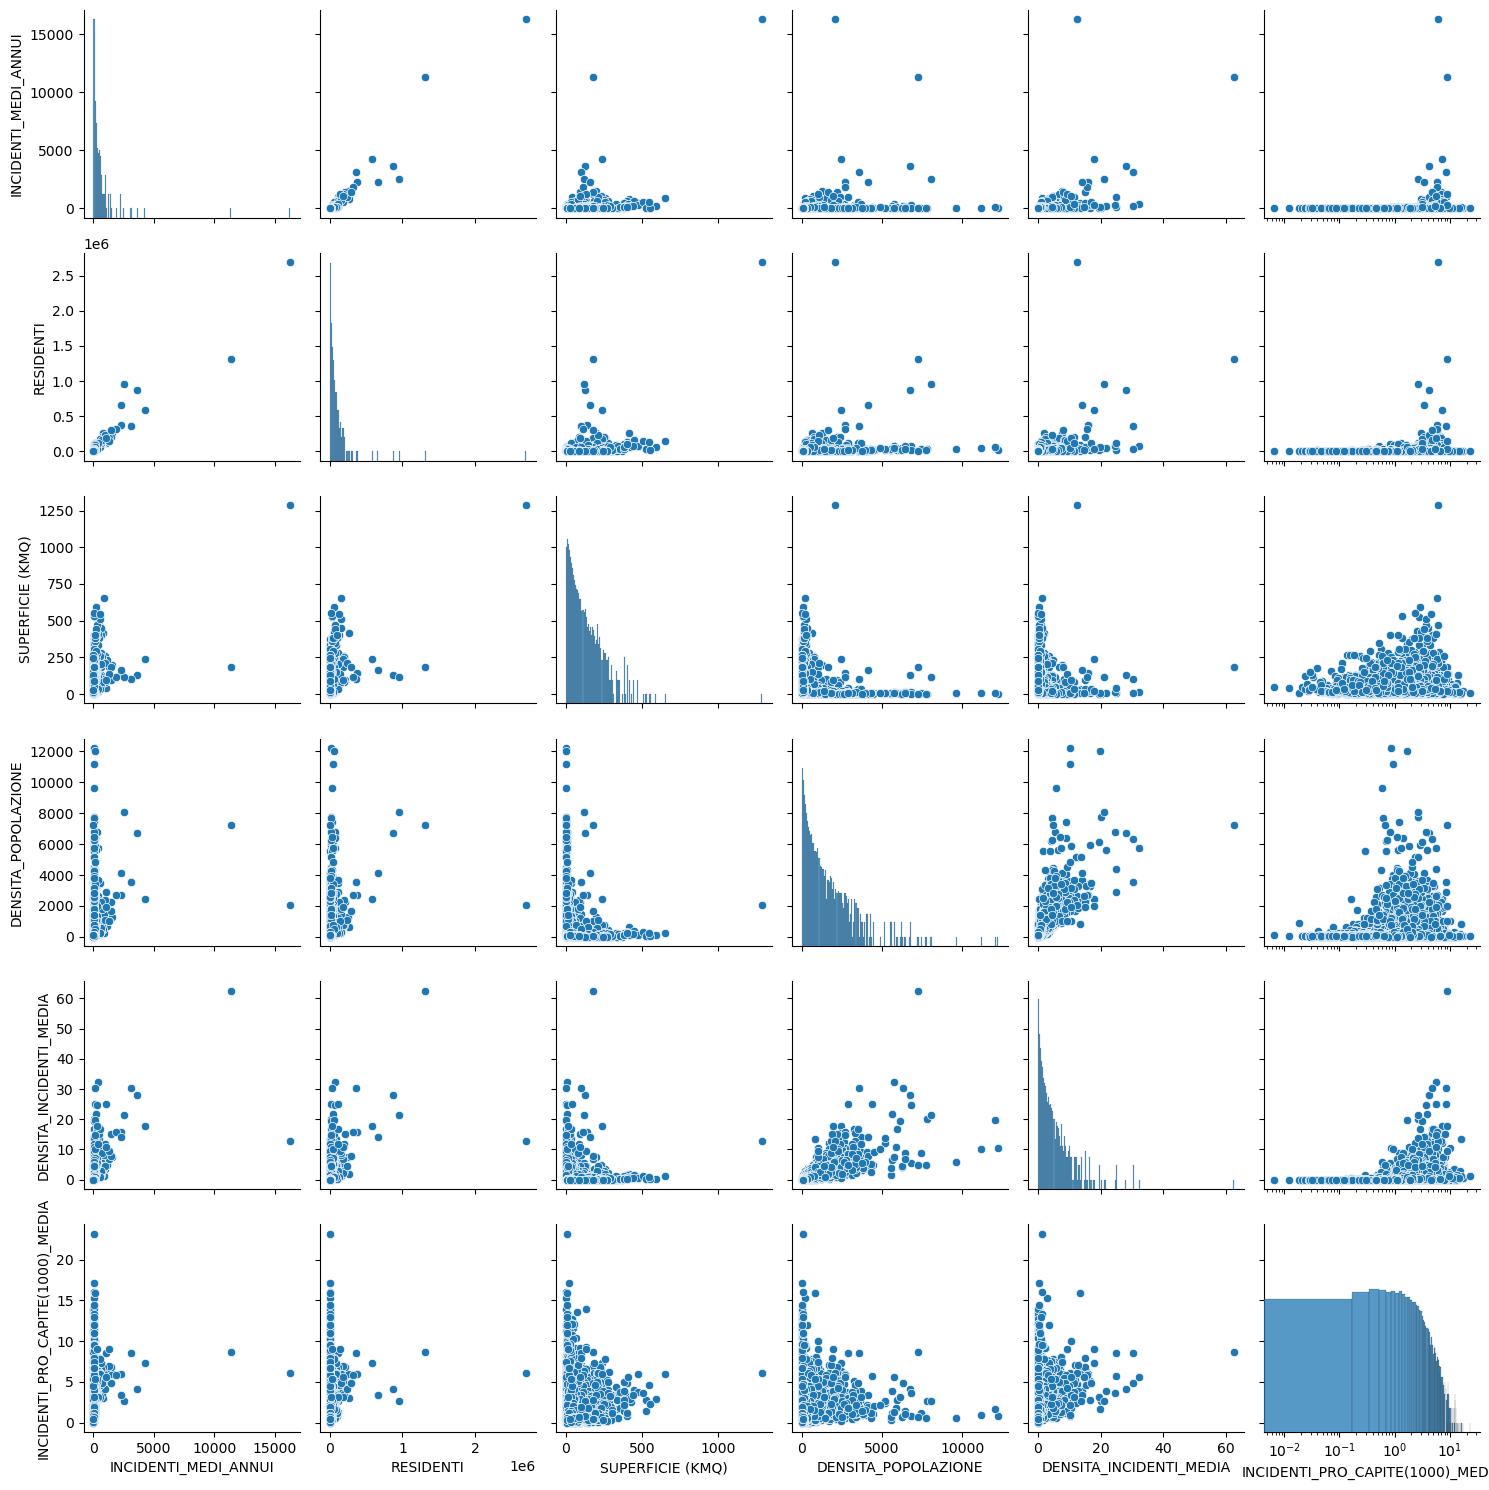

In [144]:
#PAIRPLOT
sns.pairplot(df_accidents_municipality[["INCIDENTI_MEDI_ANNUI","RESIDENTI","SUPERFICIE (KMQ)","DENSITA_POPOLAZIONE","DENSITA_INCIDENTI_MEDIA", "INCIDENTI_PRO_CAPITE(1000)_MEDIA"]])
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()


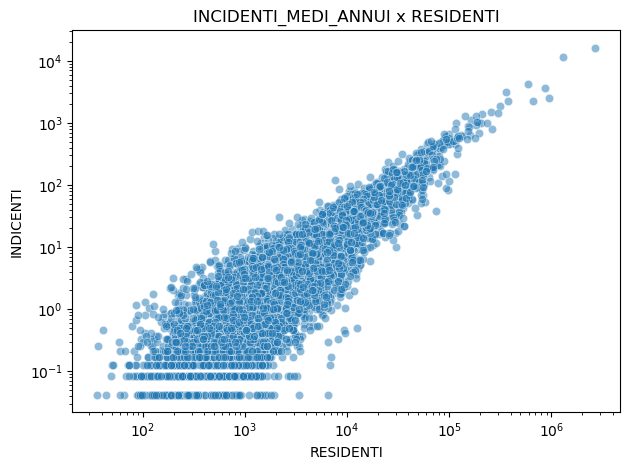

In [145]:
sns.scatterplot(data=df_accidents_municipality,x="RESIDENTI",y="INCIDENTI_MEDI_ANNUI", alpha=0.5)
plt.title("INCIDENTI_MEDI_ANNUI x RESIDENTI")
plt.ylabel("INDICENTI")
plt.xscale("log")
plt.yscale("log")
plt.tight_layout()
plt.show()

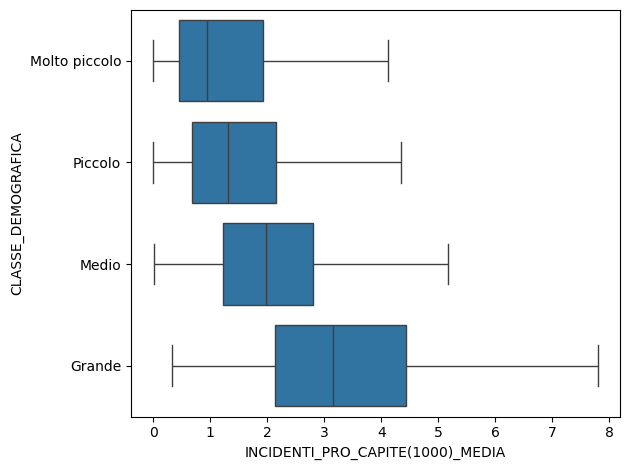

In [146]:
sns.boxplot(
    data=df_accidents_municipality,
    y="CLASSE_DEMOGRAFICA",
    x="INCIDENTI_PRO_CAPITE(1000)_MEDIA",
    order=["Molto piccolo", "Piccolo", "Medio", "Grande"],
    showfliers=False #non mostrare gli outlier nel boxplot.
)
plt.tight_layout()
plt.show()

Le mediane aumentano all' aumentare della classe demografica (si passa da circa 1 per le classi molto piccole a 3.2 per quelle Grandi).

Gli intervalli interquartili (box) si spostano verso dx.

I whiskers divengono più ampi con l' aumento della classe.

I comuni grandi sono chiaramente spostati verso destra, dunque i valori per quei comuni saranno maggiori rispetto a quelli piccoli, nella classifica che è stata fatta prima per la top incidenti pro capite medi in termini assoluti primeggiavano i molto piccoli. La differenza tra queste classi sarà da valutare con dei test successivamente.

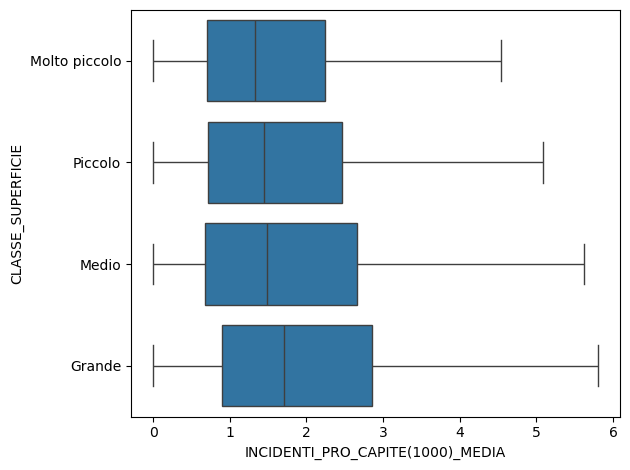

In [147]:
sns.boxplot(
    data=df_accidents_municipality,
    y="CLASSE_SUPERFICIE",
    x="INCIDENTI_PRO_CAPITE(1000)_MEDIA",
    order=["Molto piccolo", "Piccolo", "Medio", "Grande"],
    showfliers=False #non mostrare gli outlier nel boxplot.
)
plt.tight_layout()
plt.show()

Le mediane sono molto simili (circa 1.3–1.7).

Gli intervalli interquartili (box) sono quasi sovrapposti.

Anche i whisker hanno lunghezze simili.

Non c'è una classe che sia chiaramente spostata verso destra come accadeva con i comuni grandi nella classe demografica.

# CORRELAZIONI TRA VARIABILI

In [148]:
corr_accidents=df_accidents_municipality [["INCIDENTI_MEDI_ANNUI","SUPERFICIE (KMQ)","RESIDENTI", "INCIDENTI_PRO_CAPITE(1000)_MEDIA","DENSITA_INCIDENTI_MEDIA","DENSITA_POPOLAZIONE"]].corr()

corr_accidents

,INCIDENTI_MEDI_ANNUI,SUPERFICIE (KMQ),RESIDENTI,INCIDENTI_PRO_CAPITE(1000)_MEDIA,DENSITA_INCIDENTI_MEDIA,DENSITA_POPOLAZIONE
INCIDENTI_MEDI_ANNUI,1.000000,0.321485,0.958595,0.162306,0.468321,0.212585
SUPERFICIE (KMQ),0.321485,1.000000,0.371919,0.081830,-0.022891,-0.125970
RESIDENTI,0.958595,0.371919,1.000000,0.154502,0.473654,0.285340
INCIDENTI_PRO_CAPITE(1000)_MEDIA,0.162306,0.081830,0.154502,1.000000,0.348228,0.116211
DENSITA_INCIDENTI_MEDIA,0.468321,-0.022891,0.473654,0.348228,1.000000,0.763397
DENSITA_POPOLAZIONE,0.212585,-0.125970,0.285340,0.116211,0.763397,1.000000


In [149]:
df_accidents_municipality["RESIDENTI"].quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
#0.75     6115.25--> il 75% dei comuni ha meno di 6115 abitanti, dunque l' Italia si riconferma un Paese di piccoli comun a livello demografico

0.01      125.079583
0.05      295.010870
0.10      487.600000
0.25     1027.006341
0.50     2418.562500
0.75     6021.291667
0.90    13632.101923
0.95    23498.406250
0.99    68325.172500
Name: RESIDENTI, dtype: float64

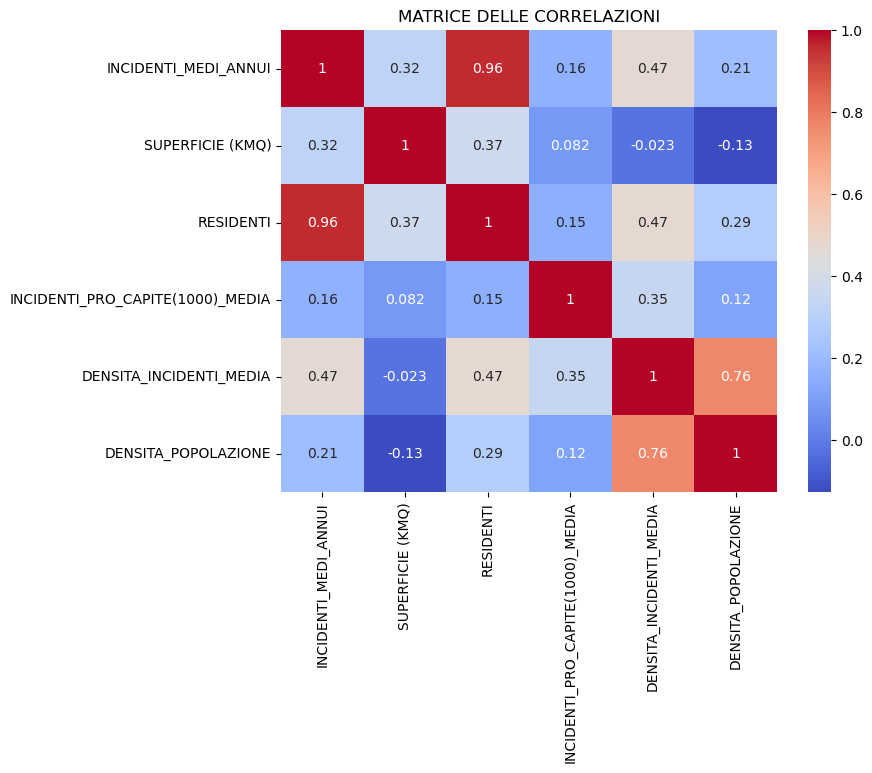

In [150]:
#Costruisco una heatmap in maniera tale da poter formulare le ipotesi che andrò a testare
plt.figure(figsize=(8, 6))
sns.heatmap(corr_accidents,annot=True,cmap="coolwarm")

plt.title("MATRICE DELLE CORRELAZIONI")
plt.show()

# ANALISI DEGLI OUTLIERS

La Classe comunale che verrà principalmente osservata per questi outlier sarà quella demografica, poichè l' incidenza degli incidenti sulla popolazione è la base della nostra analisi.

## Analisi outlier residenti
Osservo quali siano gli outlier, poichè essendoci ad esempio in residenti ed essendo questa molto correlata agli incidenti, voglio capire se siano dati falsati o abbiano un senso.

Outlier di RESIDENTI--> ci partendo da comuni con più di 13512.720 abitanti

In [151]:
outliers_lower,outliers_upper=fn.outliers(df_accidents_municipality,"RESIDENTI")
outliers_upper["CLASSE_DEMOGRAFICA"].value_counts()

ANALISI OUTLIER - RESIDENTI
Q1: 1027.006
Q3: 6021.292
IQR: 4994.285
Limite inferiore: -6464.422
Limite superiore: 13512.720
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 866
Percentuale sul totale: 10.053%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5148,58091,Roma,390605,2.693100e+06,1287.499925,12,Lazio,16275.208333,2091.728018,12.640939,6.043300,Grande,Molto grande
1875,15146,Milano,272545,1.310566e+06,181.702871,3,Lombardia,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
5533,63049,Napoli,60731,9.588668e+05,118.998133,15,Campania,2530.458333,8057.830529,21.264689,2.639009,Grande,Grande
271,1272,Torino,87227,8.728376e+05,130.021463,1,Piemonte,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
7047,82053,Palermo,54030,6.582088e+05,160.602017,19,Sicilia,2251.250000,4098.384609,14.017570,3.420267,Grande,Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7430,90070,Tempio Pausania,348,1.363354e+04,210.817515,20,Sardegna,14.500000,64.669856,0.068780,1.063554,Medio,Grande
6305,71060,Vieste,566,1.362875e+04,169.201963,16,Puglia,23.583333,80.547234,0.139380,1.730411,Medio,Grande
1928,15213,Solaro,1021,1.362700e+04,6.675996,3,Lombardia,42.541667,2041.193605,6.372333,3.121866,Medio,Molto piccolo
1886,15159,Opera,963,1.361104e+04,7.634883,3,Lombardia,40.125000,1782.743897,5.255483,2.947974,Medio,Molto piccolo


CLASSE_DEMOGRAFICA
Grande    531
Medio     335
Name: count, dtype: int64

## Analisi outlier superficie
Osservo quali siano gli outlier 

Outlier di SUPERFICIE--> il limite superiore è intorno ai 95 kmq, outliers esistono solo oltre quel limite e rappresentano 8.54% (736 comuni) sul totale, sono principalmente comuni grandi/ molto grandi.

In [152]:
outliers_lower, outliers_upper = fn.outliers(df_accidents_municipality,"SUPERFICIE (KMQ)")

outliers_upper["CLASSE_SUPERFICIE"].value_counts()

ANALISI OUTLIER - SUPERFICIE (KMQ)
Q1: 11.331
Q3: 44.802
IQR: 33.471
Limite inferiore: -38.876
Limite superiore: 95.009
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 736
Percentuale sul totale: 8.544%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5148,58091,Roma,390605,2.693100e+06,1287.499925,12,Lazio,16275.208333,2091.728018,12.640939,6.043300,Grande,Molto grande
4251,39014,Ravenna,21748,1.525028e+05,654.033092,8,Emilia-Romagna,906.166667,233.172962,1.385506,5.941966,Grande,Molto grande
6265,71020,Cerignola,4047,5.762283e+04,593.918008,16,Puglia,168.625000,97.021529,0.283920,2.926357,Grande,Molto grande
7352,89013,Noto,1304,2.369438e+04,555.023042,19,Sicilia,54.333333,42.690795,0.097894,2.293090,Grande,Molto grande
7424,90064,Sassari,13688,1.242437e+05,547.040592,20,Sardegna,570.333333,227.119648,1.042580,4.590442,Grande,Molto grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4460,43053,Tolentino,2089,1.930671e+04,95.118142,11,Marche,87.041667,202.976088,0.915090,4.508364,Medio,Medio
4016,34014,Fidenza,2459,2.572362e+04,95.116633,8,Emilia-Romagna,102.458333,270.442972,1.077186,3.983044,Grande,Medio
7257,86008,Cerami,39,2.103750e+03,95.046417,19,Sicilia,1.625000,22.133922,0.017097,0.772430,Piccolo,Medio
7054,82060,Prizzi,33,4.931417e+03,95.036283,19,Sicilia,1.375000,51.889831,0.014468,0.278825,Piccolo,Medio


CLASSE_SUPERFICIE
Grande          591
Molto grande     75
Medio            70
Name: count, dtype: int64

## Outliers incidenti medi annui

In [153]:
outliers_lower, outliers_upper= fn.outliers (df_accidents_municipality,"INCIDENTI_MEDI_ANNUI")

ANALISI OUTLIER - INCIDENTI_MEDI_ANNUI
Q1: 0.875
Q3: 10.750
IQR: 9.875
Limite inferiore: -13.938
Limite superiore: 25.562
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 1105
Percentuale sul totale: 12.828%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
5148,58091,Roma,390605,2.693100e+06,1287.499925,12,Lazio,16275.208333,2091.728018,12.640939,6.043300,Grande,Molto grande
1875,15146,Milano,272545,1.310566e+06,181.702871,3,Lombardia,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
1299,10025,Genova,102694,5.862910e+05,240.190217,7,Liguria,4278.916667,2440.944375,17.814700,7.298282,Grande,Grande
271,1272,Torino,87227,8.728376e+05,130.021463,1,Piemonte,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
4631,48017,Firenze,74537,3.646007e+05,102.315325,9,Toscana,3105.708333,3563.500466,30.354283,8.518108,Grande,Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8500,110004,Canosa di Puglia,616,2.946887e+04,150.931733,16,Puglia,25.666667,195.246328,0.170055,0.870976,Grande,Grande
2484,18069,Garlasco,616,9.592042e+03,39.175983,3,Lombardia,25.666667,244.844950,0.655163,2.675829,Medio,Piccolo
4859,54027,Marsciano,616,1.801050e+04,161.503487,10,Umbria,25.666667,111.517716,0.158923,1.425095,Medio,Grande
8506,110010,Trinitapoli,616,1.431587e+04,148.765700,16,Puglia,25.666667,96.230964,0.172531,1.792882,Medio,Grande


In [154]:
outliers_upper["CLASSE_DEMOGRAFICA"].value_counts()

CLASSE_DEMOGRAFICA
Medio      590
Grande     508
Piccolo      7
Name: count, dtype: int64

In [155]:
outliers_upper[outliers_upper["CLASSE_DEMOGRAFICA"] == "Piccolo"]

,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
1217,9012,Borghetto Santo Spirito,885,4971.916667,5.393050,7,Liguria,36.875000,921.911843,6.837504,7.416657,Piccolo,Molto piccolo
7953,97001,Abbadia Lariana,729,3206.166667,16.658875,3,Lombardia,30.375000,192.459975,1.823352,9.473930,Piccolo,Piccolo
4006,34004,Berceto,726,2160.958333,131.704583,8,Emilia-Romagna,30.250000,16.407617,0.229681,13.998419,Piccolo,Grande
4255,39018,Solarolo,711,4416.416667,26.038283,8,Emilia-Romagna,29.625000,169.612436,1.137748,6.707927,Piccolo,Piccolo
1262,9057,Spotorno,682,3753.791667,8.019750,7,Liguria,28.416667,468.068414,3.543336,7.570124,Piccolo,Molto piccolo
4828,53024,Scarlino,656,3659.125000,88.267629,9,Toscana,27.333333,41.454892,0.309664,7.469910,Piccolo,Medio
4196,37051,San Benedetto Val di Sambro,621,4354.041667,66.492137,8,Emilia-Romagna,25.875000,65.482053,0.389144,5.942754,Piccolo,Medio


In [156]:
outliers_upper_region = (outliers_upper.groupby("REGIONE", as_index=False)
                         .agg(NUM_COMUNI=("COMUNE", "count"),
                              COMUNI=("COMUNE", ", ".join)))

outliers_upper_region.sort_values("NUM_COMUNI", ascending=False)

,REGIONE,NUM_COMUNI,COMUNI
8,Lombardia,198,"Milano, Brescia, Bergamo, Como, Pavia, Cremona..."
4,Emilia-Romagna,126,"Bologna, Rimini, Modena, Reggio nell'Emilia, P..."
19,Veneto,121,"Verona, Padova, Venezia, Vicenza, Treviso, Chi..."
15,Toscana,101,"Firenze, Prato, Livorno, Pisa, Lucca, Viareggi..."
12,Puglia,87,"Bari, Taranto, Foggia, Lecce, Brindisi, Altamu..."
14,Sicilia,73,"Palermo, Catania, Messina, Siracusa, Trapani, ..."
3,Campania,70,"Napoli, Salerno, Pozzuoli, Caserta, Battipagli..."
6,Lazio,65,"Roma, Latina, Fiumicino, Viterbo, Aprilia, Rie..."
11,Piemonte,57,"Torino, Alessandria, Novara, Asti, Cuneo, Biel..."
9,Marche,39,"Pesaro, Ancona, Fano, San Benedetto del Tronto..."


## Outliers densità incidenti media

In [157]:
outliers_lower, outliers_upper= fn.outliers (df_accidents_municipality,"DENSITA_INCIDENTI_MEDIA")
outliers_upper["CLASSE_DEMOGRAFICA"].value_counts()

ANALISI OUTLIER - DENSITA_INCIDENTI_MEDIA
Q1: 0.037
Q3: 0.527
IQR: 0.490
Limite inferiore: -0.698
Limite superiore: 1.262
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 1058
Percentuale sul totale: 12.282%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
1875,15146,Milano,272545,1.310566e+06,181.702871,3,Lombardia,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
1827,15077,Cinisello Balsamo,9859,7.300467e+04,12.724083,3,Lombardia,410.791667,5737.518747,32.284578,5.626923,Grande,Piccolo
4631,48017,Firenze,74537,3.646007e+05,102.315325,9,Toscana,3105.708333,3563.500466,30.354283,8.518108,Grande,Grande
1838,15093,Corsico,3901,3.376558e+04,5.358042,3,Lombardia,162.541667,6301.851578,30.336021,4.813827,Grande,Molto piccolo
271,1272,Torino,87227,8.728376e+05,130.021463,1,Piemonte,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5254,60043,Isola del Liri,486,1.163046e+04,16.009617,12,Lazio,20.250000,726.467009,1.264865,1.741118,Medio,Piccolo
3722,28106,Due Carrare,806,8.823208e+03,26.564417,5,Veneto,33.583333,332.143877,1.264223,3.806250,Medio,Piccolo
8090,98045,Pieve Fissiraga,372,1.630333e+03,12.265287,3,Lombardia,15.500000,132.922553,1.263729,9.507258,Piccolo,Piccolo
3611,27037,Scorzè,1009,1.873758e+04,33.287217,5,Veneto,42.041667,562.906281,1.262997,2.243708,Medio,Piccolo


CLASSE_DEMOGRAFICA
Medio            543
Grande           352
Piccolo          154
Molto piccolo      9
Name: count, dtype: int64

In [158]:
#Outliers di classe demografica piccolo e molto piccolo raggruppato per regione con numero di comuni
(outliers_upper[outliers_upper["CLASSE_DEMOGRAFICA"].isin(["Piccolo", "Molto piccolo"])].groupby("REGIONE").agg(NUM_COMUNI=("COMUNE", "count"),
                                                                                                                COMUNI=("COMUNE", ", ".join))
                                                                                                                .sort_values(by="NUM_COMUNI",ascending=False))

,NUM_COMUNI,COMUNI
REGIONE,,
Lombardia,111,"Malgrate, Pescate, Grandate, Buguggiate, Lozza..."
Liguria,15,"Borghetto Santo Spirito, Laigueglia, Borgio Ve..."
Piemonte,9,"Gaglianico, Dormelletto, Paruzzaro, Banchette,..."
Marche,5,"Numana, Castelbellino, Pedaso, Colli del Tront..."
Campania,5,"Atrani, Lacco Ameno, Conca dei Marini, Minori,..."
Veneto,5,"Battaglia Terme, Pastrengo, Nove, Grisignano d..."
Trentino-Alto Adige,4,"Fiera di Primiero, Nogaredo, San Michele all'A..."
Sicilia,3,"Aci Bonaccorsi, Valdina, Venetico"
Lazio,2,"Colonna, Nazzano"


In [159]:
#Outliers di classe demografica totale raggruppato per regione con numero di comuni
outliers_upper_region = (outliers_upper.groupby("REGIONE", as_index=False)
                         .agg(NUM_COMUNI=("COMUNE", "count"),
                              COMUNI=("COMUNE", ", ".join)))

outliers_upper_region.sort_values("NUM_COMUNI", ascending=False)

,REGIONE,NUM_COMUNI,COMUNI
7,Lombardia,436,"Milano, Cinisello Balsamo, Corsico, Cormano, B..."
2,Campania,119,"Napoli, Portici, Aversa, Casavatore, San Giorg..."
18,Veneto,99,"Padova, Verona, Treviso, Vicenza, Conegliano, ..."
10,Piemonte,56,"Torino, Collegno, Beinasco, Nichelino, Gruglia..."
14,Toscana,51,"Firenze, Viareggio, Forte dei Marmi, Prato, Ca..."
6,Liguria,49,"Genova, Chiavari, Albissola Marina, Vallecrosi..."
3,Emilia-Romagna,48,"Riccione, Bologna, Cattolica, Rimini, Casalecc..."
13,Sicilia,44,"Palermo, Gravina di Catania, Villabate, Sant'A..."
5,Lazio,38,"Roma, Ciampino, Frosinone, Albano Laziale, Anz..."
8,Marche,35,"San Benedetto del Tronto, Gabicce Mare, Civita..."


## Outliers incidenti pro capite media

In [160]:
outliers_lower, outliers_upper= fn.outliers (df_accidents_municipality,"DENSITA_INCIDENTI_MEDIA")


ANALISI OUTLIER - DENSITA_INCIDENTI_MEDIA
Q1: 0.037
Q3: 0.527
IQR: 0.490
Limite inferiore: -0.698
Limite superiore: 1.262
----------------------------------------------------------------------
-OUTLIER INFERIORI
Numero di comuni: 0
Percentuale sul totale: 0.000%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE


-OUTLIER SUPERIORI
Numero di comuni: 1058
Percentuale sul totale: 12.282%


,ID_COMUNE,COMUNE,INCIDENTI_TOTALI,RESIDENTI,SUPERFICIE (KMQ),ID_REGIONE,REGIONE,INCIDENTI_MEDI_ANNUI,DENSITA_POPOLAZIONE,DENSITA_INCIDENTI_MEDIA,INCIDENTI_PRO_CAPITE(1000)_MEDIA,CLASSE_DEMOGRAFICA,CLASSE_SUPERFICIE
1875,15146,Milano,272545,1.310566e+06,181.702871,3,Lombardia,11356.041667,7212.689425,62.497866,8.664988,Grande,Grande
1827,15077,Cinisello Balsamo,9859,7.300467e+04,12.724083,3,Lombardia,410.791667,5737.518747,32.284578,5.626923,Grande,Piccolo
4631,48017,Firenze,74537,3.646007e+05,102.315325,9,Toscana,3105.708333,3563.500466,30.354283,8.518108,Grande,Grande
1838,15093,Corsico,3901,3.376558e+04,5.358042,3,Lombardia,162.541667,6301.851578,30.336021,4.813827,Grande,Molto piccolo
271,1272,Torino,87227,8.728376e+05,130.021463,1,Piemonte,3634.458333,6713.027282,27.952757,4.163957,Grande,Grande
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5254,60043,Isola del Liri,486,1.163046e+04,16.009617,12,Lazio,20.250000,726.467009,1.264865,1.741118,Medio,Piccolo
3722,28106,Due Carrare,806,8.823208e+03,26.564417,5,Veneto,33.583333,332.143877,1.264223,3.806250,Medio,Piccolo
8090,98045,Pieve Fissiraga,372,1.630333e+03,12.265287,3,Lombardia,15.500000,132.922553,1.263729,9.507258,Piccolo,Piccolo
3611,27037,Scorzè,1009,1.873758e+04,33.287217,5,Veneto,42.041667,562.906281,1.262997,2.243708,Medio,Piccolo


In [161]:
df_accidents_municipality.to_csv("../Data/Df_clean/df_accidents_municipality_aggregate_years.csv",index=False)